In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('customer_behavior.csv')
df.head()


,CustomerID,Gender,Region,PurchaseAmount,ProductCategory,Churn,CampaignGroup
0,1001,Male,South,256.07,Fashion,No,A
1,1002,Female,South,NaN,Electronics,Yes,B
2,1003,Female,West,1194.41,Fashion,No,A
3,1004,Female,South,413.06,Grocery,No,A
4,1005,Male,West,1556.32,Fashion,Yes,A


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerID       5000 non-null   int64  
 1   Gender           4903 non-null   str    
 2   Region           4825 non-null   str    
 3   PurchaseAmount   4850 non-null   float64
 4   ProductCategory  4474 non-null   str    
 5   Churn            4735 non-null   str    
 6   CampaignGroup    4815 non-null   str    
dtypes: float64(1), int64(1), str(5)
memory usage: 273.6 KB


In [4]:
#What is the average, median, and mode of PurchaseAmount?
purchase_mean = df["PurchaseAmount"].mean()
purchase_median = df["PurchaseAmount"].median()
purchase_mode = df["PurchaseAmount"].mode()[0]

print("Average Purchase Amount:", purchase_mean)
print("Median Purchase Amount:", purchase_median)
print("Mode Purchase Amount:", purchase_mode)

Average Purchase Amount: 1003.9506701030928
Median Purchase Amount: 998.0799999999999
Mode Purchase Amount: 0.0


In [5]:
#Are there any outliers in the PurchaseAmount data?
df["PurchaseAmount"] = df["PurchaseAmount"].fillna(purchase_mean)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerID       5000 non-null   int64  
 1   Gender           4903 non-null   str    
 2   Region           4825 non-null   str    
 3   PurchaseAmount   5000 non-null   float64
 4   ProductCategory  4474 non-null   str    
 5   Churn            4735 non-null   str    
 6   CampaignGroup    4815 non-null   str    
dtypes: float64(1), int64(1), str(5)
memory usage: 273.6 KB


In [7]:
from scipy.stats import zscore

# IQR outlayer  finder  method
def IQR_outliers_finder(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    #IQR
    IQR = Q3 - Q1
    #Lower and Upper Boundaries
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower) | (df[column] > upper)]
    return outliers

# percental outlayer  finder  method
def Percent_outliers_finder(df, column):
  #Percentiles
    P5 = np.percentile(df[column], 5)
    P95 = np.percentile(df[column], 95)
    outliers = df[(df[column] < P5) | (df[column] > P95)]
    return outliers

#z score outlayer  finder  method
def z_score_outliers_finder(df, column):
    df["z_score"] = zscore(df[column])
    outliers = df[df["z_score"].abs() > 2]
    return outliers


In [8]:
z_score_out = z_score_outliers_finder(df,"PurchaseAmount")
print("z_score outliers are \n",z_score_out["PurchaseAmount"])

z_score outliers are 
 36         0.00
37      2209.39
40        13.96
55      2049.70
57      2079.56
         ...   
4894    2251.62
4898       0.00
4944    2078.61
4976       0.00
4981       0.00
Name: PurchaseAmount, Length: 255, dtype: float64


In [9]:
iqr_out = IQR_outliers_finder(df, "PurchaseAmount")
print("IQR_outliers are \n",iqr_out["PurchaseAmount"])

IQR_outliers are 
 195     2318.33
265     2496.41
348     2688.69
411     2349.16
442     2291.79
702     2292.99
826     2578.89
1358    2384.19
1792    2265.18
2285    2457.05
2455    2286.38
2557    2316.19
2681    2400.69
3326    2357.41
3438    2688.88
3564    2643.88
3697    2261.69
3711    2301.24
4005    2290.15
4088    2273.03
4270    2262.25
4345    2472.62
4693    2484.75
4808    2642.06
Name: PurchaseAmount, dtype: float64


In [10]:
Percent_out = Percent_outliers_finder(df, "PurchaseAmount")
print("Percentil outliers are \n",iqr_out["PurchaseAmount"])

Percentil outliers are 
 195     2318.33
265     2496.41
348     2688.69
411     2349.16
442     2291.79
702     2292.99
826     2578.89
1358    2384.19
1792    2265.18
2285    2457.05
2455    2286.38
2557    2316.19
2681    2400.69
3326    2357.41
3438    2688.88
3564    2643.88
3697    2261.69
3711    2301.24
4005    2290.15
4088    2273.03
4270    2262.25
4345    2472.62
4693    2484.75
4808    2642.06
Name: PurchaseAmount, dtype: float64


In [ ]:
#please find above outliers

In [14]:
from scipy.stats import kurtosis
from scipy.stats import skew
print("skewnes  ", skew(df['PurchaseAmount']))
print("kurtosis ",kurtosis(df['PurchaseAmount']))


skewnes   0.10768667914138372
kurtosis  -0.1778122600130425


In [15]:
#Is there a significant difference in spending between male and female customers?
df.groupby("Gender")["PurchaseAmount"].mean()


Gender
Female     988.365256
Male      1018.730610
Name: PurchaseAmount, dtype: float64

not big difference , male is a bit high

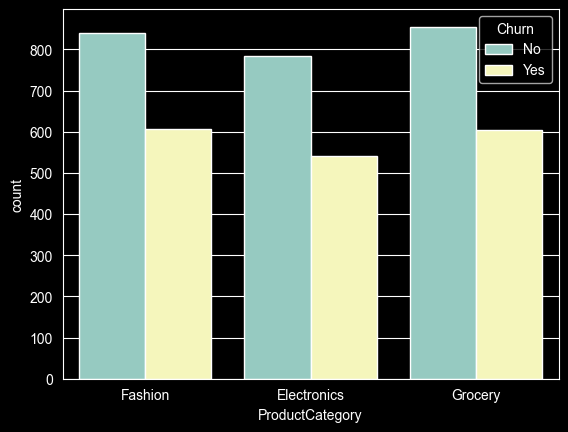

In [17]:
# 5. Is there a relationship between ProductCategory and customer churn?
sns.countplot(data=df, x="ProductCategory",hue="Churn")
plt.show()

Electronics	is less churn

In [18]:
# Does PurchaseAmount vary significantly across different regions?
df['Region'] = df['Region'].ffill().bfill()
df.info()
df_sale = df.groupby("Region",as_index=False)["PurchaseAmount"].sum()
df_sale

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerID       5000 non-null   int64  
 1   Gender           4903 non-null   str    
 2   Region           5000 non-null   str    
 3   PurchaseAmount   5000 non-null   float64
 4   ProductCategory  4474 non-null   str    
 5   Churn            4735 non-null   str    
 6   CampaignGroup    4815 non-null   str    
 7   z_score          5000 non-null   float64
dtypes: float64(2), int64(1), str(5)
memory usage: 312.6 KB


,Region,PurchaseAmount
0,East,1.273237e+06
1,North,1.284232e+06
2,South,1.290190e+06
3,West,1.172094e+06


PurchaseAmount not vary significantly across different regions

In [ ]:
#

In [19]:
#Which email campaign (A or B) performed better in terms of average PurchaseAmount?
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerID       5000 non-null   int64  
 1   Gender           4903 non-null   str    
 2   Region           5000 non-null   str    
 3   PurchaseAmount   5000 non-null   float64
 4   ProductCategory  4474 non-null   str    
 5   Churn            4735 non-null   str    
 6   CampaignGroup    4815 non-null   str    
 7   z_score          5000 non-null   float64
dtypes: float64(2), int64(1), str(5)
memory usage: 312.6 KB


In [23]:
df = df[df['CampaignGroup'].notna()]
df.info()


<class 'pandas.DataFrame'>
Index: 4815 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerID       4815 non-null   int64  
 1   Gender           4721 non-null   str    
 2   Region           4815 non-null   str    
 3   PurchaseAmount   4815 non-null   float64
 4   ProductCategory  4302 non-null   str    
 5   Churn            4555 non-null   str    
 6   CampaignGroup    4815 non-null   str    
 7   z_score          4815 non-null   float64
dtypes: float64(2), int64(1), str(5)
memory usage: 338.6 KB


In [24]:
df.groupby("CampaignGroup")["PurchaseAmount"].mean()

CampaignGroup
A    1011.663336
B     994.586394
Name: PurchaseAmount, dtype: float64

 CampaignGroup A performed better

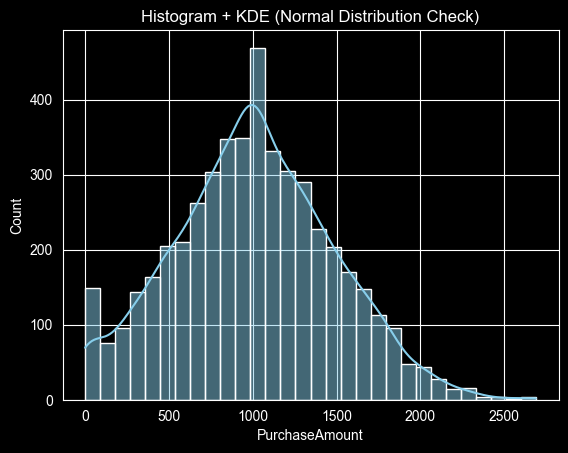

In [25]:
#Can we assume PurchaseAmount follows a normal distribution?
sns.histplot(data=df, x="PurchaseAmount", kde=True, bins=30, color="skyblue")
plt.title("Histogram + KDE (Normal Distribution Check)")
plt.show()


curve looks bell‑shaped with gentle tails, that confirms near‑normality

What insights can we gain by applying the Central Limit Theorem?
When you take many random samples from any population (no matter its original shape) and compute their means, the distribution of those sample means will tend to be normal as the sample size grows.


In [28]:
#10.What is the 95% confidence interval for the average PurchaseAmount?

import statsmodels.stats.api as sms

stats_obj = sms.DescrStatsW(df['PurchaseAmount'])

ci_low, ci_high = stats_obj.zconfint_mean(alpha=0.05)   # use z confident because it is more than 30
(ci_low, ci_high)


(np.float64(989.7713033041206), np.float64(1016.6805839254351))

95% confident that the average PurchaseAmount is between 989.771and 1016.680